<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 4: Clasificador de Imágenes con CNN / Transfer Learning</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Entrenar un clasificador de imágenes sobre EuroSAT imágenes satelitales de uso de suelo (10 clases), usando una CNN propia o transfer learning con un modelo preentrenado, y comparar resultados.
</div>


**EuroSAT** contiene 27 000 imágenes a color de $64\times64$ píxeles tomadas por el satélite Sentinel-2, clasificadas en 10 tipos de terreno: cultivos, bosque, vegetación, autopista, zona industrial, pastizal, cultivo permanente, zona residencial, río y lago/mar. Es un dominio **distinto** a los datasets clásicos (dígitos, ropa u objetos cotidianos), lo que lo hace ideal para practicar.


## Instrucciones

1. Carga **EuroSAT** con `torchvision.datasets.EuroSAT` y **divídelo** en entrenamiento/validación (no trae partición predefinida).
2. Aplica **data augmentation** al conjunto de entrenamiento (p. ej. volteos y rotaciones).
3. **Opción A:** define una **CNN desde cero**. **Opción B:** usa **ResNet18 preentrenada** (transfer learning) — recuerda redimensionar a $224\times224$ y normalizar con las medias/desviaciones de ImageNet.
4. Entrena y evalúa; reporta la **precisión en validación**.
5. Muestra algunas **predicciones** con sus imágenes (acierto/error).
6. Muestra la **matriz de confusión** e identifica qué clases se confunden más.
7. (Bonus) Compara **CNN propia vs. transfer learning**.

> La sección **0** (carga y visualización) ya está resuelta; tú completas los **TODO** de modelo, entrenamiento y predicción.

> **Entrega:** notebook ejecutado con tus conclusiones.


### 0. Carga y exploración del dataset (EuroSAT)

Esta parte ya está resuelta: descarga EuroSAT (solo la primera vez, ~90 MB), lo divide en entrenamiento/validación y muestra algunos ejemplos con su clase. Reutilizarás `train_ds`, `val_ds`, `train_loader`, `val_loader` y `clases` en el resto de la actividad.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Descarga EuroSAT (imágenes 64x64 RGB) y lo divide en 80% train / 20% validación
base = datasets.EuroSAT(root='./data', download=True, transform=transforms.ToTensor())
clases = base.classes
n_val = int(0.2 * len(base))
train_ds, val_ds = random_split(base, [len(base) - n_val, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)

print("Total:", len(base), "| Entrenamiento:", len(train_ds), "| Validación:", len(val_ds))
print("Clases (10):", clases)

100%|██████████| 94.3M/94.3M [00:06<00:00, 14.8MB/s]


Total: 27000 | Entrenamiento: 21600 | Validación: 5400
Clases (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


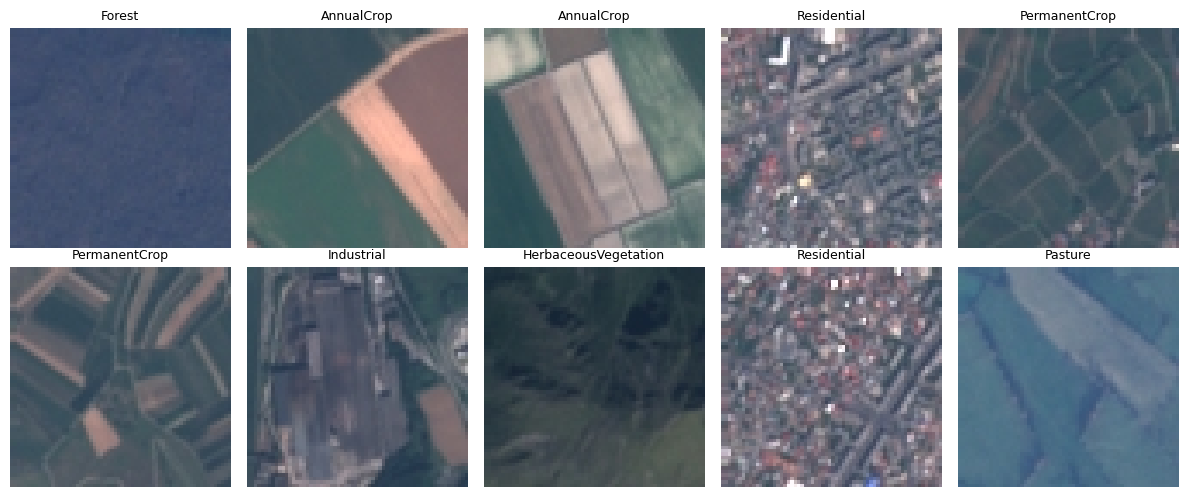

In [2]:
# Visualizar 10 imágenes satelitales con su clase
plt.figure(figsize=(12, 5))
for i in range(10):
    img, label = train_ds[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(img.permute(1, 2, 0).numpy())   # de [C,H,W] a [H,W,C]
    plt.title(clases[label], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Paso 1 (opcional): data augmentation para el conjunto de entrenamiento.
# Las imágenes ya se cargaron con ToTensor en la Sección 0. Si quieres augmentation,
# redefine las transformaciones y reconstruye train_loader.
#
# TODO: define transforms con aumento (p. ej. RandomHorizontalFlip, RandomRotation)
#       Para ResNet18 (Opción B): Resize(224) + Normalize con medias/std de ImageNet
#       ImageNet -> mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]




In [ ]:
# Paso 2: define tu modelo. Entrada: imágenes 3x64x64 | Salida: 10 clases
#
# Opción A (CNN propia): apila bloques Conv2d -> ReLU -> MaxPool2d, luego Flatten + Linear.
#   import torch.nn as nn
#   model = nn.Sequential( ... )  o  una clase nn.Module
#
# Opción B (transfer learning con ResNet18 preentrenada):
#   from torchvision import models
#   from torchvision.models import ResNet18_Weights
#   model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
#   # congela parámetros y reemplaza model.fc por nn.Linear(model.fc.in_features, 10)
#
# Recuerda mover el modelo al dispositivo: model.to(device)
# TODO: define aquí tu modelo

In [ ]:
# Paso 3: entrenamiento y evaluación
#
# TODO:
#   - criterion = nn.CrossEntropyLoss()
#   - optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
#   - bucle por épocas: zero_grad -> forward -> loss -> backward -> step
#   - guarda la pérdida/accuracy por época y evalúa en val_loader
#   - reporta la precisión final en validación

In [ ]:
# Paso 4: visualiza predicciones y la matriz de confusión
#
# TODO:
#   - toma un lote de val_loader, predice y muestra las imágenes con
#     su clase predicha (verde si acierta, rojo si falla)
#   - construye la matriz de confusión:
#       from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay